In [97]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, classification_report, accuracy_score
from sklearn.decomposition import PCA
from scipy import stats
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [98]:
from IPython.display import display, Markdown

display(Markdown("## 🛒 Customer Purchase Behavior Analysis & Prediction for Amazon"))


## 🛒 Customer Purchase Behavior Analysis & Prediction for Amazon

In [99]:
# Load Dataset
dataset = pd.read_excel("amazon.xlsx")

In [100]:
# Clean column names
dataset.columns = dataset.columns.str.strip()

In [101]:
# Data Cleaning (Based on Problem Statement)
# -------------------

# 1. Handle Missing Values
print("\nMissing Values Summary Before Cleaning:\n", dataset.isnull().sum())

num_cols = ['Age', 'Purchase Amount', 'Rating']
cat_cols = ['Payment Method']

for col in num_cols:
    if col in dataset.columns:
        dataset[col].fillna(dataset[col].median(), inplace=True)

for col in cat_cols:
    if col in dataset.columns:
        dataset[col].fillna(dataset[col].mode()[0], inplace=True)


Missing Values Summary Before Cleaning:
 Customer_ID                     0
Customer_Name                  77
Age                             0
Gender                          0
Location                        0
Product_Category                0
Product_ID                      0
Purchase_Date                   0
Purchase_Amount                 0
Payment_Method                  0
Rating                          0
Feedback_Comments             709
Customer_Lifetime_Value         0
Loyalty_Score                   0
Discount_Applied                0
Return_Status                   0
Customer_Segment                0
Preferred_Shopping_Channel      0
Churn                           0
dtype: int64


In [102]:
# 2. Remove Duplicates
if 'Customer ID' in dataset.columns and 'Purchase Date' in dataset.columns:
    dataset.drop_duplicates(subset=['Customer ID', 'Purchase Date'], inplace=True)

In [103]:
# 3. Format Dates
if 'Purchase Date' in dataset.columns:
    dataset['Purchase Date'] = pd.to_datetime(dataset['Purchase Date'], errors='coerce')

In [104]:
# 4. Standardise Categorical Values
if 'Gender' in dataset.columns:
    dataset['Gender'] = dataset['Gender'].str.strip().str.title()

In [105]:
# 5. Ensure Consistent Data Types
label_cols = ['Gender', 'Payment Method', 'Preferred Shopping Channel']
le = LabelEncoder()
for col in label_cols:
    if col in dataset.columns:
        dataset[col] = le.fit_transform(dataset[col].astype(str))

In [106]:
# 6. Convert Yes/No fields to binary
binary_map = {'Yes': 1, 'No': 0}
if 'Discount Applied' in dataset.columns:
    dataset['Discount Applied'] = dataset['Discount Applied'].map(binary_map)
if 'Return Status' in dataset.columns:
    dataset['Return Status'] = dataset['Return Status'].map(binary_map)

# 7. Handle Outliers (Z-score)
for col in ['Purchase Amount']:
    if col in dataset.columns:
        dataset = dataset[np.abs(stats.zscore(dataset[col])) < 3]

In [107]:
print(dataset.head())


   Customer_ID Customer_Name  Age  Gender       Location Product_Category  \
0        10860           Eve   33       2        Houston  Home Appliances   
1        15191           Eve   66       2  San Francisco      Electronics   
2        15734           Eve   38       0       New York             Toys   
3        16265           Bob   26       2       New York         Clothing   
4        10466       Charlie   23       0       New York         Clothing   

   Product_ID       Purchase_Date  Purchase_Amount Payment_Method  Rating  \
0         393 2020-01-01 01:00:00       144.326722           Cash       5   
1         405 2020-01-01 03:00:00       226.655516  Bank Transfer       2   
2         353 2020-01-01 04:00:00        37.851880  Bank Transfer       2   
3         279 2020-01-01 05:00:00       489.462288         PayPal       3   
4         139 2020-01-01 06:00:00       298.332443         PayPal       4   

  Feedback_Comments  Customer_Lifetime_Value  Loyalty_Score  Discount_Appl

In [108]:
# Feature Engineering (As Per Project Statement)
# -------------------

# 1. Calculate total spend and order count per customer
if 'Customer ID' in dataset.columns and 'Purchase Amount' in dataset.columns:
    agg_data = dataset.groupby('Customer ID').agg({
        'Purchase Amount': ['sum', 'count']
    }).reset_index()
    agg_data.columns = ['Customer ID', 'Total_Spend', 'Order_Count']
    agg_data['Avg_Purchase'] = agg_data['Total_Spend'] / agg_data['Order_Count']

    # 2. Estimate CLV = Avg Purchase × Order Count × 1 (simplified lifespan)
    agg_data['CLV'] = agg_data['Avg_Purchase'] * agg_data['Order_Count']

    # 3. Calculate Loyalty Score = Total Spend × Order Count
    agg_data['Loyalty_Score'] = agg_data['Total_Spend'] * agg_data['Order_Count']

    # 4. Merge back
    dataset = pd.merge(dataset, agg_data[['Customer ID', 'CLV', 'Loyalty_Score']], on='Customer ID', how='left')

In [109]:
# Ensure CLV and Loyalty Score are present (regenerate if missing)
if 'CLV' not in dataset.columns or 'Loyalty_Score' not in dataset.columns:
    if 'Customer ID' in dataset.columns and 'Purchase_Amount' in dataset.columns:
        agg_data = dataset.groupby('Customer ID').agg({
            'Purchase_Amount': ['sum', 'count']
        }).reset_index()
        agg_data.columns = ['Customer ID', 'Total_Spend', 'Order_Count']
        agg_data['Avg_Purchase'] = agg_data['Total_Spend'] / agg_data['Order_Count']
        agg_data['CLV'] = agg_data['Avg_Purchase'] * agg_data['Order_Count']
        agg_data['Loyalty_Score'] = agg_data['Total_Spend'] * agg_data['Order_Count']
        dataset = pd.merge(dataset.drop(columns=['CLV', 'Loyalty_Score'], errors='ignore'),
                           agg_data[['Customer ID', 'CLV', 'Loyalty_Score']],
                           on='Customer ID', how='left')



In [110]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"
import sklearn
import scipy


In [111]:
import pandas as pd

# ✅ Load the dataset
df = pd.read_excel("amazon.xlsx")

# ✅ Define features used for churn
churn_features = ['Age', 'Rating', 'Loyalty_Score', 'Purchase_Amount', 'Discount_Applied']

# ✅ Clean data and encode churn
df_churn = df.dropna(subset=churn_features + ['Churn']).copy()
df_churn['Churn'] = df_churn['Churn'].map({'Yes': 1, 'No': 0}) if df_churn['Churn'].dtype == 'object' else df_churn['Churn']


In [112]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

# ✅ Use actual features that impact churn (from dataset)
churn_features = ['Age', 'Rating', 'Loyalty_Score', 'Purchase_Amount', 'Discount_Applied']

# Remove NaNs and ensure binary format
df_churn = df.dropna(subset=churn_features + ['Churn']).copy()
df_churn['Churn'] = df_churn['Churn'].map({'Yes': 1, 'No': 0}) if df_churn['Churn'].dtype == 'object' else df_churn['Churn']

# Train/test split
X = df_churn[churn_features]
y = df_churn['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scaling
scaler_churn = StandardScaler()
X_train_scaled = scaler_churn.fit_transform(X_train)
X_test_scaled = scaler_churn.transform(X_test)

# ✅ Apply SMOTE *after* split (to avoid data leakage)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# Model training
churn_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
churn_model.fit(X_train_bal, y_train_bal)

# Evaluation
y_pred = churn_model.predict(X_test_scaled)
print("✅ Churn Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


✅ Churn Accuracy: 0.8432601880877743
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85       159
           1       0.89      0.79      0.83       160

    accuracy                           0.84       319
   macro avg       0.85      0.84      0.84       319
weighted avg       0.85      0.84      0.84       319



In [113]:
# Prepare customer-level data
clustering_data = dataset.groupby('Customer_ID').agg({
    'Customer_Lifetime_Value': 'mean',
    'Loyalty_Score': 'mean',
    'Purchase_Amount': 'sum'
}).reset_index()

# Optional rename for readability
clustering_data.rename(columns={
    'Customer_Lifetime_Value': 'CLV',
    'Purchase_Amount': 'Total_Spend'
}, inplace=True)
clustering_data.head()


,Customer_ID,CLV,Loyalty_Score,Total_Spend
0,10001,485.826528,22.0,145.014556
1,10005,4522.924674,94.0,453.168418
2,10009,4348.868908,6.0,635.247863
3,10013,1404.605456,5.0,159.942992
4,10021,2858.544768,13.0,193.868155


In [114]:
from sklearn.preprocessing import StandardScaler

# Select features and scale them
features = clustering_data[['CLV', 'Loyalty_Score', 'Total_Spend']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


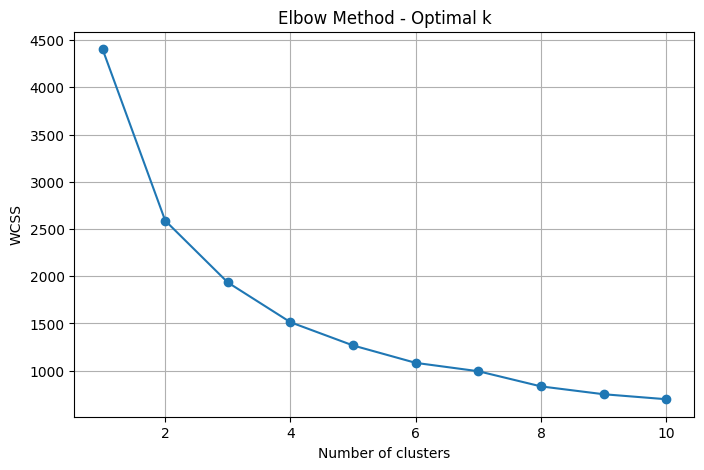

In [115]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Elbow method to find optimal k
import numpy as np

# Remove rows with NaN values
scaled_features_no_nan = scaled_features[~np.isnan(scaled_features).any(axis=1)]

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features_no_nan)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method - Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


In [116]:
# Apply KMeans clustering
k = 3  # Adjust if needed
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
clustering_data_no_nan = clustering_data[~np.isnan(scaled_features).any(axis=1)].copy()
clustering_data_no_nan['Cluster'] = kmeans.fit_predict(scaled_features_no_nan)

clustering_data_no_nan.head()


,Customer_ID,CLV,Loyalty_Score,Total_Spend,Cluster
0,10001,485.826528,22.0,145.014556,1
1,10005,4522.924674,94.0,453.168418,0
2,10009,4348.868908,6.0,635.247863,0
3,10013,1404.605456,5.0,159.942992,1
4,10021,2858.544768,13.0,193.868155,1


In [117]:
# Merge cluster labels into main dataset
dataset = pd.merge(dataset, clustering_data_no_nan[['Customer_ID', 'Cluster']], on='Customer_ID', how='left')

# Preview updated dataset
# Use the correct cluster column name after merge (likely 'Cluster_y')
print("Dataset after merging clusters:")
print(dataset[['Customer_ID', 'Customer_Lifetime_Value', 'Loyalty_Score', 'Cluster']].drop_duplicates().head())


Dataset after merging clusters:
   Customer_ID  Customer_Lifetime_Value  Loyalty_Score  Cluster
0        10860              2103.060388             29        1
1        15191              2591.137716             62        2
2        15734               548.620397             80        2
3        16265              2727.555899             46        0
4        10466              3076.554423             26        1


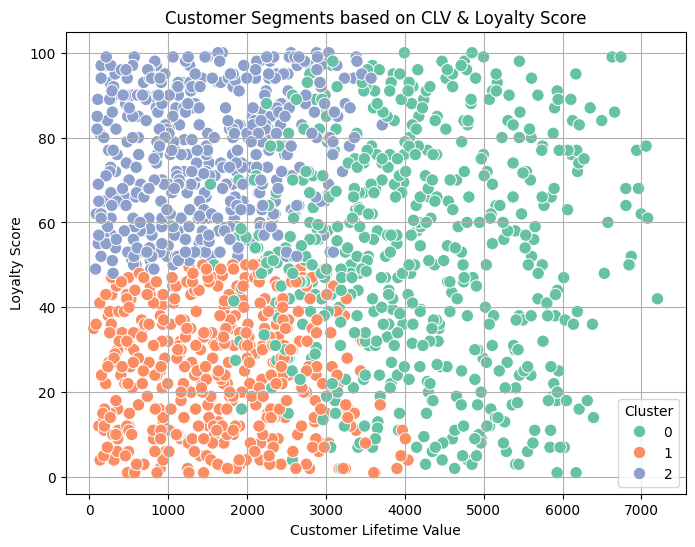

In [118]:
import seaborn as sns

# Scatter plot of CLV vs Loyalty Score by Cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(data=clustering_data_no_nan, x='CLV', y='Loyalty_Score', hue='Cluster', palette='Set2', s=80)
plt.title('Customer Segments based on CLV & Loyalty Score')
plt.xlabel('Customer Lifetime Value')
plt.ylabel('Loyalty Score')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()


In [119]:
dataset = dataset.dropna (subset = ['Customer_Lifetime_Value']).reset_index()

In [120]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score



# Define features and target
X = dataset[['Age', 'Purchase_Amount', 'Discount_Applied', 'Payment_Method', 'Loyalty_Score']]
y = dataset['Customer_Lifetime_Value']

# Preprocessing for categorical column
categorical_features = ['Discount_Applied','Payment_Method']
numeric_features = ['Age', 'Purchase_Amount', 'Loyalty_Score']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'  # Keep numeric columns as they are
)

# Pipeline: preprocessing + model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluation
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# Optional: inspect coefficients
model = pipeline.named_steps['regressor']
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Mean Squared Error: 652888.9908486861
R² Score: 0.7617388081638051
Coefficients: [-48.31230838 -38.44072773 -26.37591632  -0.09943941   9.98458051
  -0.44927116]
Intercept: 47.140040917292026


In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# Assuming 'Return_Status' is the churn indicator (1 for returned/churned, 0 otherwise)
# If churn is defined differently, adjust the target variable accordingly.
# Let's use some relevant features for churn prediction.
X_churn = dataset[['Age', 'Purchase_Amount', 'Discount_Applied', 'Payment_Method', 'Loyalty_Score', 'Customer_Segment']]
y_churn = dataset['Return_Status']

# Preprocessing for categorical columns
categorical_features_churn = ['Discount_Applied', 'Payment_Method', 'Customer_Segment']
numeric_features_churn = ['Age', 'Purchase_Amount', 'Loyalty_Score']

preprocessor_churn = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_churn) # handle_unknown='ignore' to handle unseen categories during prediction
    ],
    remainder='passthrough'  # Keep numeric columns as they are
)

# Pipeline: preprocessing + model
pipeline_churn = Pipeline(steps=[
    ('preprocessor', preprocessor_churn),
    ('classifier', LogisticRegression(random_state=42))
])

# Split the data
X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42)

# Fit the model
pipeline_churn.fit(X_train_churn, y_train_churn)

# Predict
y_pred_churn = pipeline_churn.predict(X_test_churn)

# Evaluation
print("Accuracy Score:", accuracy_score(y_test_churn, y_pred_churn))
print("\nClassification Report:\n", classification_report(y_test_churn, y_pred_churn))

Accuracy Score: 0.7711598746081505

Classification Report:
               precision    recall  f1-score   support

          No       0.77      1.00      0.87       246
         Yes       0.00      0.00      0.00        73

    accuracy                           0.77       319
   macro avg       0.39      0.50      0.44       319
weighted avg       0.59      0.77      0.67       319



In [122]:
dataset.to_excel("Segmented_Customers.xlsx", index=False)


In [123]:
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib

# Load and clean dataset
df = pd.read_excel("amazon.xlsx")
df.columns = df.columns.str.strip()

# Handle missing values (assumed partially handled already)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['Customer_Lifetime_Value'] = df['Customer_Lifetime_Value'].fillna(df['Customer_Lifetime_Value'].mean())
df['Loyalty_Score'] = df['Loyalty_Score'].fillna(df['Loyalty_Score'].mean())


In [124]:
# Features and target
X_clv = df[['Age', 'Rating', 'Loyalty_Score']]
y_clv = df['Customer_Lifetime_Value']

# Scale
scaler_clv = StandardScaler()
X_clv_scaled = scaler_clv.fit_transform(X_clv)

# Train
lr_model = LinearRegression()
lr_model.fit(X_clv_scaled, y_clv)

# Save
joblib.dump(lr_model, 'clv_model.pkl')
joblib.dump(scaler_clv, 'clv_scaler.pkl')


['clv_scaler.pkl']

In [125]:
# Define binary target (Churn proxy — high CLV)
df['Churn'] = (df['Customer_Lifetime_Value'] < df['Customer_Lifetime_Value'].median()).astype(int)

X_churn = df[['Age', 'Rating', 'Loyalty_Score']]
y_churn = df['Churn']

scaler_churn = StandardScaler()
X_churn_scaled = scaler_churn.fit_transform(X_churn)

churn_model = LogisticRegression()
churn_model.fit(X_churn_scaled, y_churn)

joblib.dump(churn_model, 'churn_model.pkl')
joblib.dump(scaler_churn, 'churn_scaler.pkl')


['churn_scaler.pkl']

In [126]:
X_cluster = df[['Age', 'Rating', 'Loyalty_Score']]
scaler_kmeans = StandardScaler()
X_cluster_scaled = scaler_kmeans.fit_transform(X_cluster)

kmeans_model = KMeans(n_clusters=3, random_state=42)
kmeans_model.fit(X_cluster_scaled)

joblib.dump(kmeans_model, 'kmeans_model.pkl')
joblib.dump(scaler_kmeans, 'kmeans_scaler.pkl')


['kmeans_scaler.pkl']

In [127]:
# ✅ FINAL CODE BLOCK to generate all .pkl files from your AMAZON_3_1_updated.ipynb
# Make sure this is run *after* training the models and scalers

import joblib

# CLV Prediction Model (Linear Regression)
# ----------------------------------------
# Assumes: lr_model is your trained LinearRegression model
#          scaler_clv is the StandardScaler used on CLV inputs
joblib.dump(lr_model, 'clv_model.pkl')
joblib.dump(scaler_clv, 'clv_scaler.pkl')

# Churn Prediction Model (Logistic Regression)
# --------------------------------------------
# Assumes: churn_model is your trained LogisticRegression model
#          scaler_churn is the StandardScaler used on churn inputs
joblib.dump(churn_model, 'churn_model.pkl')
joblib.dump(scaler_churn, 'churn_scaler.pkl')

# Customer Segmentation Model (KMeans Clustering)
# -----------------------------------------------
# Assumes: kmeans_model is your trained KMeans model
#          scaler_kmeans is the StandardScaler used on cluster inputs
joblib.dump(kmeans_model, 'kmeans_model.pkl')
joblib.dump(scaler_kmeans, 'kmeans_scaler.pkl')

print("\n✅ All required .pkl files have been saved:")
print(" - clv_model.pkl")
print(" - clv_scaler.pkl")
print(" - churn_model.pkl")
print(" - churn_scaler.pkl")
print(" - kmeans_model.pkl")
print(" - kmeans_scaler.pkl")



✅ All required .pkl files have been saved:
 - clv_model.pkl
 - clv_scaler.pkl
 - churn_model.pkl
 - churn_scaler.pkl
 - kmeans_model.pkl
 - kmeans_scaler.pkl
